In [18]:
import pandas as pd
import numpy as np

df = pd.read_csv("../data/raw/online_retail.csv")

# Display first 5 rows
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [3]:
# Shape
print("Shape:", df.shape)

# Column names
print("\nColumns:\n", df.columns)

# Data types
print("\nData Types:\n", df.dtypes)

# Missing values
print("\nMissing Values:\n", df.isnull().sum())

Shape: (1067371, 8)

Columns:
 Index(['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'Price', 'Customer ID', 'Country'],
      dtype='object')

Data Types:
 Invoice         object
StockCode       object
Description     object
Quantity         int64
InvoiceDate     object
Price          float64
Customer ID    float64
Country         object
dtype: object

Missing Values:
 Invoice             0
StockCode           0
Description      4382
Quantity            0
InvoiceDate         0
Price               0
Customer ID    243007
Country             0
dtype: int64


In [23]:
df["Customer ID"].nunique()

5942

In [24]:
df[df["Quantity"] < 0].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


In [25]:
df[df["Invoice"].astype(str).str.startswith("C")].head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
178,C489449,22087,PAPER BUNTING WHITE LACE,-12,2009-12-01 10:33:00,2.95,16321.0,Australia
179,C489449,85206A,CREAM FELT EASTER EGG BASKET,-6,2009-12-01 10:33:00,1.65,16321.0,Australia
180,C489449,21895,POTTING SHED SOW 'N' GROW SET,-4,2009-12-01 10:33:00,4.25,16321.0,Australia
181,C489449,21896,POTTING SHED TWINE,-6,2009-12-01 10:33:00,2.10,16321.0,Australia
182,C489449,22083,PAPER CHAIN KIT RETRO SPOT,-12,2009-12-01 10:33:00,2.95,16321.0,Australia


## Initial Data Observations
---

### Dataset Overview
- **Total Rows:** 1,067,371  
- **Total Columns:** 8  
- **Unique Customers:** 5,942  

### Data Quality Issues
- **Missing Customer IDs:** 243,007  
  → This may impact customer-level analysis.

- **Negative Quantities Present:**  
  → Indicates product returns.

- **Cancelled Invoices:**  
  → Invoice numbers starting with **"C"** represent cancellations.

### Next Step
Data cleaning is required before:
- Revenue analysis  
- Customer analysis  
- Segmentation

## Data Cleaning
---

In [7]:
# Create a working copy
df_clean = df.copy()

print("Initial Shape:", df_clean.shape)

Initial Shape: (1067371, 8)


In [8]:
df_clean = df_clean[~df_clean["Invoice"].astype(str).str.startswith("C")]

print("After removing cancellations:", df_clean.shape)

After removing cancellations: (1047877, 8)


In [9]:
df_clean = df_clean[df_clean["Quantity"] > 0]

print("After removing negative quantities:", df_clean.shape)

After removing negative quantities: (1044420, 8)


In [10]:
df_clean = df_clean[df_clean["Customer ID"].notnull()]

print("After removing missing Customer IDs:", df_clean.shape)

After removing missing Customer IDs: (805620, 8)


In [11]:
df_clean["InvoiceDate"] = pd.to_datetime(df_clean["InvoiceDate"])
df_clean.dtypes

Invoice                object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
Price                 float64
Customer ID           float64
Country                object
dtype: object

In [12]:
#Revenue = Quantity × Price

df_clean["Revenue"] = df_clean["Quantity"] * df_clean["Price"]
df_clean.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,Revenue
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


In [13]:
print("Final Cleaned Shape:", df_clean.shape)
print("Unique Customers:", df_clean["Customer ID"].nunique())
print("Total Revenue:", df_clean["Revenue"].sum())

Final Cleaned Shape: (805620, 9)
Unique Customers: 5881
Total Revenue: 17743429.178000007


## Data Cleaning Summary
---
The following preprocessing steps were performed on the dataset:

- Removed cancelled invoices  
- Removed negative quantity transactions (returns)  
- Removed records with missing Customer IDs  
- Converted `InvoiceDate` to datetime format  
- Created a new column **Revenue** (`Quantity × Price`)  

The cleaned dataset is now ready for:

- 📊 Revenue analysis  
- 👥 Customer analysis  

## Revenue Analysis
---

In [14]:
df_clean["YearMonth"] = df_clean["InvoiceDate"].dt.to_period("M")

In [15]:
monthly_revenue = df_clean.groupby("YearMonth")["Revenue"].sum().reset_index()

monthly_revenue.head()

,YearMonth,Revenue
0,2009-12,686654.160
1,2010-01,557319.062
2,2010-02,506371.066
3,2010-03,699608.991
4,2010-04,594609.192


In [22]:
#Convert Period to String (for plotting)
monthly_revenue["YearMonth"] = monthly_revenue["YearMonth"].astype(str)

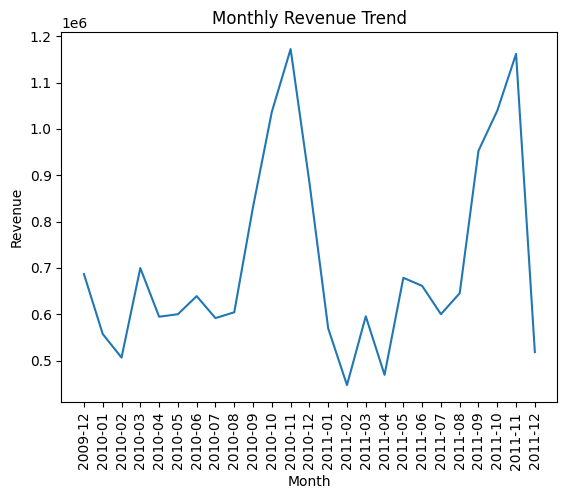

In [17]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(monthly_revenue["YearMonth"], monthly_revenue["Revenue"])
plt.xticks(rotation=90)
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.show()

In [27]:
#Top Countries by Revenue
country_revenue = (
    df_clean.groupby("Country")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

country_revenue

Country
United Kingdom    1.472315e+07
EIRE              6.216311e+05
Netherlands       5.542323e+05
Germany           4.312625e+05
France            3.552575e+05
Australia         1.699681e+05
Spain             1.091785e+05
Switzerland       1.003653e+05
Sweden            9.154972e+04
Denmark           6.986219e+04
Name: Revenue, dtype: float64

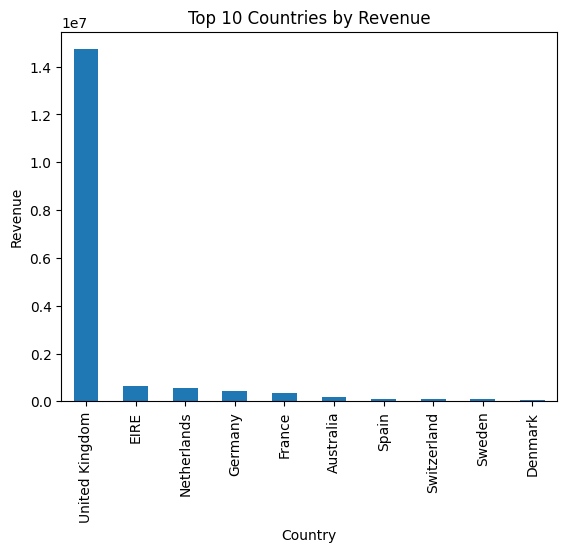

In [28]:
plt.figure()
country_revenue.plot(kind="bar")
plt.title("Top 10 Countries by Revenue")
plt.ylabel("Revenue")
plt.show()

In [29]:
#AOV = Total Revenue / Total Unique Invoices
total_revenue = df_clean["Revenue"].sum()
total_orders = df_clean["Invoice"].nunique()

aov = total_revenue / total_orders

print("Average Order Value:", round(aov, 2))

Average Order Value: 479.88


In [31]:
#Revenue per customer
customer_revenue = (
    df_clean.groupby("Customer ID")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

customer_revenue.head()

Customer ID
18102.0    608821.65
14646.0    528602.52
14156.0    313946.37
14911.0    295972.63
17450.0    246973.09
Name: Revenue, dtype: float64

In [33]:
top_20_percent = int(len(customer_revenue) * 0.2)

top_revenue = customer_revenue.head(top_20_percent).sum()
total_revenue = customer_revenue.sum()
print("Top 20% revenue contribution:", round((top_revenue / total_revenue) * 100, 2), "%")

Top 20% revenue contribution: 77.26 %


## 📊 Revenue Insights
---
### Revenue Trend Analysis

Monthly revenue exhibits noticeable fluctuations over time, indicating the presence of seasonal purchasing patterns. Specific months show significant revenue peaks, which may correspond to promotional campaigns, holidays, or periods of increased consumer demand.

### Geographic Revenue Distribution

Revenue contribution is concentrated among the top-performing countries, with the leading market accounting for a substantial share of total sales. This indicates strong regional performance but also highlights potential dependency risk if demand weakens in key markets.

### Average Order Value (AOV)

The **Average Order Value (AOV)** is **479.88 per order**.

AOV represents the average transaction size and serves as a key profitability indicator. This metric can potentially be improved through:
- Strategic product bundling  
- Cross-selling and upselling initiatives  
- Minimum order value incentives  
- Targeted promotional campaigns  

### Revenue Concentration (Pareto Analysis)

The **top 20% of customers contribute approximately 77.26% of total revenue**, indicating a high degree of revenue concentration.

This underscores the strategic importance of:
- Retaining high-value customers  
- Implementing loyalty programs  
- Personalizing customer engagement  
- Strengthening long-term customer relationships  